# Median + IQR SHAP Networks for NHANES I dataset Random Forest Model

This notebook implements robust aggregation using median and interquartile range (IQR) for uncertainty quantification.

**Approach:** Use median instead of mean for aggregation (robust to outliers) and compute IQR to quantify variability/uncertainty in feature importance across patients. This provides both a robust summary and uncertainty bounds.

## Robust Aggregation: IQR-Inspired Percentile-Based Uncertainty

We define a tolerance parameter γ ∈ [0, 50] based on the Interquartile Range (IQR). This parameter defines percentile bounds around the median:
- We compute the (50-γ)-th and (50+γ)-th percentiles for each agent across all patients
- When γ = 25, we obtain the classical IQR (25th and 75th percentiles)
- The parameter γ controls how strict we are about sign consistency

**Color scheme for classification:**
- **Positive (risk) nodes:** Both percentiles are positive → at least (50+γ)% of patients have a positive effect
- **Negative (protective) nodes:** Both percentiles are negative → at least (50+γ)% of patients have a negative effect
- **Gray (mixed-sign) nodes:** Percentiles have different signs → tolerance band crosses zero, indicating different effects in different patients

The same classification applies to interaction effects (edges).

In [1]:
import os
import sys
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cgt_perezsechi.visualization.graph import draw
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r

c:\Workspace\IJAR\IJAR-python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Configure matplotlib for VS Code Jupyter
%matplotlib inline
# Set pandas display options to avoid truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_info_columns', 99999)

In [3]:
# Load data
X = pd.read_pickle("../../../../data/nhanesi/x_values.pkl")
num_patients = 500
X_shapley = X.iloc[:num_patients, :]
shap_values = np.load("../../../../data/nhanesi/rf/shap_values.npy")
shap_interaction_values = np.load("../../../../data/nhanesi/rf/shap_interaction_values.npy")

## Configuration: Tolerance Parameter γ

Set the tolerance parameter γ ∈ [0, 50] for percentile-based uncertainty quantification:
- γ = 25 → classical IQR (25th and 75th percentiles)
- Larger γ → stricter consistency requirements (more gray nodes)
- Smaller γ → more permissive thresholds (fewer gray nodes)

In [4]:
# Tolerance parameter for percentile-based uncertainty
gamma = 15  # Classical IQR when γ = 25

# Compute percentile bounds
lower_percentile = 50 - gamma  # e.g., 25th percentile when γ = 25
upper_percentile = 50 + gamma  # e.g., 75th percentile when γ = 25

print(f"Using γ = {gamma}")
print(f"Computing {lower_percentile}th and {upper_percentile}th percentiles")
print(f"This means at least {upper_percentile}% of patients must agree on sign for consistent classification")

Using γ = 15
Computing 35th and 65th percentiles
This means at least 65% of patients must agree on sign for consistent classification


## Build Median-Based SHAP Values (psi_1)

In [5]:
shap_values_clean = np.nan_to_num(shap_values)
n_features = shap_values_clean.shape[1]

# Calculate median SHAP values across patients
median_shap = np.median(shap_values_clean, axis=0)

# Calculate percentiles using γ parameter
# When γ = 25, this gives classical IQR (25th to 75th percentile)
q_lower_shap = np.percentile(shap_values_clean, lower_percentile, axis=0)
q_upper_shap = np.percentile(shap_values_clean, upper_percentile, axis=0)
iqr_shap = q_upper_shap - q_lower_shap

# Calculate absolute median for normalization
sum_abs_median_shap = np.sum(np.abs(median_shap))

# Build psi matrices
psi_1_median = pd.DataFrame()
psi_1_median['value'] = median_shap / sum_abs_median_shap
psi_1_median['iqr'] = iqr_shap / sum_abs_median_shap
psi_1_median[f'q25'] = q_lower_shap / sum_abs_median_shap
psi_1_median[f'q75'] = q_upper_shap / sum_abs_median_shap
psi_1_median['cv'] = iqr_shap / (np.abs(median_shap) + 1e-10)  # Coefficient of variation
psi_1_median.set_index(X_shapley.columns, inplace=True)

print(f"Median-based node weights (psi) with uncertainty (γ = {gamma}):")
print(psi_1_median.head(10))

Median-based node weights (psi) with uncertainty (γ = 15):
                                        value       iqr       q25       q75  \
sex_isFemale                        -0.069955  0.154791 -0.078027  0.076765   
age                                 -0.773982  1.039085 -1.105679 -0.066594   
physical_activity                   -0.003276  0.001638 -0.003767 -0.002129   
serum_albumin                       -0.008392  0.011909 -0.009711  0.002198   
alkaline_phosphatase                -0.017786  0.011436 -0.020114 -0.008678   
alkaline_phosphatase_isUnacceptable -0.000006  0.000007 -0.000011 -0.000004   
alkaline_phosphatase_isTestnotdone   0.000006  0.000004  0.000004  0.000008   
SGOT                                -0.001130  0.004175 -0.001916  0.002259   
SGOT_isUnacceptable                 -0.000206  0.000076 -0.000231 -0.000155   
SGOT_isTestnotdone                  -0.000003  0.000002 -0.000005 -0.000003   

                                           cv  
sex_isFemale           

## Build Median-Based Interaction Values (r_1)

In [6]:
# Remove diagonal
n_variables = shap_interaction_values.shape[1]
filtered_shap_interaction_values = np.nan_to_num(shap_interaction_values.copy())
idx_patients = np.repeat(np.arange(num_patients), n_variables)
idx_variables = np.tile(np.arange(n_variables), num_patients)
filtered_shap_interaction_values[idx_patients, idx_variables, idx_variables] = 0

# Calculate median interaction values across patients
median_interaction = np.median(filtered_shap_interaction_values, axis=0)

# Calculate percentiles using γ parameter for interactions
q_lower_interaction = np.percentile(filtered_shap_interaction_values, lower_percentile, axis=0)
q_upper_interaction = np.percentile(filtered_shap_interaction_values, upper_percentile, axis=0)
iqr_interaction = q_upper_interaction - q_lower_interaction

# Normalize
sum_abs_median_interaction = np.sum(np.abs(median_interaction))

# Build r_1 with uncertainty
r_1_median = pd.DataFrame(median_interaction / sum_abs_median_interaction)
r_1_median.rename(columns=dict(list(zip(r_1_median.columns, X_shapley.columns))), inplace=True)
r_1_median.set_index(X_shapley.columns, inplace=True)

# Store IQR separately
r_1_iqr = pd.DataFrame(iqr_interaction / sum_abs_median_interaction)
r_1_iqr.rename(columns=dict(list(zip(r_1_iqr.columns, X_shapley.columns))), inplace=True)
r_1_iqr.set_index(X_shapley.columns, inplace=True)

print(f"\nMedian-based edge weights (r) computed with γ = {gamma}")
print(f"Mean IQR for interactions: {iqr_interaction.mean():.6f}")


Median-based edge weights (r) computed with γ = 15
Mean IQR for interactions: 0.000610


In [7]:
# Store lower and upper percentiles for interactions
r_1_q_lower = pd.DataFrame(q_lower_interaction / sum_abs_median_interaction)
r_1_q_lower.rename(columns=dict(list(zip(r_1_q_lower.columns, X_shapley.columns))), inplace=True)
r_1_q_lower.set_index(X_shapley.columns, inplace=True)

r_1_q_upper = pd.DataFrame(q_upper_interaction / sum_abs_median_interaction)
r_1_q_upper.rename(columns=dict(list(zip(r_1_q_upper.columns, X_shapley.columns))), inplace=True)
r_1_q_upper.set_index(X_shapley.columns, inplace=True)

print(f"Lower ({lower_percentile}th) and upper ({upper_percentile}th) percentile dataframes created for interactions")

Lower (35th) and upper (65th) percentile dataframes created for interactions


## Normalize Matrices

In [8]:
from IPython.display import display, Math

# Create psi_1 with just the value column for normalization
psi_1 = psi_1_median[['value']].copy()
psi_2 = normalize_psi(psi_1)
r_2 = normalize_r(r_1_median)

display(Math(r"\mathcal{N}^*_i = \frac{\mathrm{median}_t \left( Sh_{i}(\Delta^{t}) \right)}{\sum_{u=1}^{n} \left| \mathrm{median}_t \left( Sh_{u}(\Delta^{t}) \right) \right|}"))
display(psi_2)
display(Math(r"\mathcal{E}^*_{ij} = \frac{\mathrm{median}_t \left( I_{ij}(\Delta^{t}) \right)}{\sum_{v=1}^{n} \sum_{u > v}^{n} \left| \mathrm{median}_t \left( I_{uv}(\Delta^{t}) \right) \right|}"))
display(r_2)

<IPython.core.display.Math object>

,value
sex_isFemale,-9.038264e-02
age,-1.000000e+00
physical_activity,-4.232819e-03
serum_albumin,-1.084325e-02
alkaline_phosphatase,-2.297931e-02
alkaline_phosphatase_isUnacceptable,-7.351977e-06
alkaline_phosphatase_isTestnotdone,7.859781e-06
SGOT,-1.459345e-03
SGOT_isUnacceptable,-2.656998e-04
SGOT_isTestnotdone,-3.442439e-06


<IPython.core.display.Math object>

,sex_isFemale,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,BUN,BUN_isUnacceptable,BUN_isTestnotdone,calcium,calcium_isUnacceptable,calcium_isTestnotdone,creatinine,creatinine_isUnacceptable,creatinine_isTestnotdone,potassium,potassium_isUnacceptable,sodium,sodium_isUnacceptable,total_bilirubin,total_bilirubin_isUnacceptable,total_bilirubin_isTestnotdone,serum_protein,red_blood_cells,red_blood_cells_isUnacceptable,red_blood_cells_isBlankbutapplicable,white_blood_cells,white_blood_cells_isUnacceptable,white_blood_cells_isBlankbutapplicable,hemoglobin,hemoglobin_isMissing,hematocrit,hematocrit_isUnacceptable,hematocrit_isMissing,platelets_isNormal,platelets_isIncreased,platelets_isDecreased,platelets_isNoestimate,segmented_neutrophils,lymphocytes,monocytes,eosinophils,basophils,band_neutrophils,cholesterol,cholesterol_isMissing,urine_albumin_isNegative,urine_albumin_is>=30,urine_albumin_is>=100,urine_albumin_is>=300,urine_albumin_is>=1000,urine_albumin_isTrace,urine_albumin_isBlankbutapplicable,urine_glucose_isNegative,urine_glucose_isLight,urine_glucose_isMedium,urine_glucose_isDark,urine_glucose_isVerydark,urine_glucose_isTrace,urine_glucose_isBlankbutapplicable,urine_pH,urine_pH_isBlankbutapplicable,urine_hematest_isNegative,urine_hematest_isSmall,urine_hematest_isModerate,urine_hematest_isLarge,urine_hematest_isBlankbutapplicable,sedimentation_rate,sedimentation_rate_isBlankbutapplicable,uric_acid,uric_acid_isUnacceptable,uric_acid_isTestnotdone,systolic_blood_pressure,pulse_pressure,bmi
sex_isFemale,0.000000,1.000000,-4.289010e-02,-3.582801e-03,-3.762118e-02,0.000000,-0.000032,-4.622554e-03,-0.001792,0.000000,-0.005364,-1.549074e-04,0.0,-3.660431e-03,-6.707374e-05,-2.360399e-04,-0.001475,0.000424,0.0,-7.233450e-04,-0.000087,7.401686e-05,0.000000,-0.023237,-0.000123,-0.000463,4.945594e-03,4.444714e-03,0.000243,-0.000344,2.281915e-02,2.815040e-05,-0.000641,-2.375063e-02,0.0,-7.520153e-03,0.000002,0.0,0.000004,0.000014,0.000000,0.0,0.000438,-7.256158e-04,-2.228304e-03,0.001020,0.000826,1.300398e-04,1.128628e-02,0.0,-3.841644e-05,3.054914e-04,0.000000e+00,0.000000e+00,0.0,-2.878490e-04,-0.000158,-2.639976e-03,0.000000e+00,0.000000e+00,-9.817371e-05,-6.463489e-05,0.0,-1.369601e-04,4.594060e-04,-5.309932e-04,-0.000271,8.202160e-05,0.0,0.0,0.000009,-4.864149e-02,3.118046e-05,-5.408533e-03,0.0,-1.040874e-04,-6.499841e-02,-0.035552,0.024672
age,1.000000,0.000000,1.025715e-01,3.772504e-02,-1.306817e-01,0.000124,-0.000117,-7.276199e-02,0.006000,0.000082,-0.029268,3.357063e-04,0.0,-4.155297e-03,-1.494494e-04,-4.916582e-05,-0.006506,-0.002262,0.0,-5.769729e-02,0.000266,-1.902631e-02,0.000118,-0.064450,0.003550,-0.000100,3.271355e-03,2.703689e-02,0.001948,0.000312,8.384167e-02,-3.921425e-04,0.001828,9.405063e-02,0.0,8.416954e-02,0.000002,0.0,-0.000336,0.000025,0.000103,0.0,-0.007672,-5.113205e-03,-4.096740e-03,-0.003754,-0.001226,-2.082175e-03,-9.747582e-02,0.0,9.329427e-03,3.444196e-03,-1.185561e-03,1.902200e-04,0.0,-3.356414e-04,-0.000865,2.112292e-02,9.795927e-05,-1.539788e-04,1.150582e-02,2.181509e-04,0.0,-2.865781e-05,-6.941227e-04,-6.198506e-04,0.000455,-7.876542e-04,0.0,0.0,0.000489,3.838090e-02,2.419616e-04,-1.208746e-02,0.0,-6.631291e-05,2.880555e-01,0.185803,0.050582
physical_activity,-0.042890,0.102571,0.000000e+00,-7.056660e-04,-1.816197e-04,-0.000032,0.000000,-4.301568e-04,0.000000,0.000000,-0.000309,0.000000e+00,0.0,-4.930873e-04,0.000000e+00,-4.327236e-07,0.000000,0.000026,0.0,1.770683e-05,0.000000,-1.302128e-05,0.000000,-0.001852,-0.000018,0.000000,-8.868884e-04,-1.236967e-03,0.000000,0.000000,5.594490e-04,0.000000e+00,0.000021,-9.549634e-05,0.0,-7.294244e-04,0.000000,0.0,0.000000,0.000033,0.000000,0.0,-0.000026,-8.089375e-05,-1.754262e-04,0.000007,-0.000211,3.497972e-05,8.073963e-04,0.0,4.999418e-05,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,-0.000007,1.126837e-06,0.000000e+00,0.00000

## Visualization

In [9]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(0.0)[:3]
negative_color = shap_cmap(1.0)[:3]

positive_alpha = 0.01
negative_alpha = 0.01
positive_beta = 0
negative_beta = 0

In [10]:
positive_color

(np.float64(0.0),
 np.float64(0.5433775692459107),
 np.float64(0.983379062301401))

Saving the graph to ..\..\..\..\result\nhanesi_rf_iqr_network.jpg


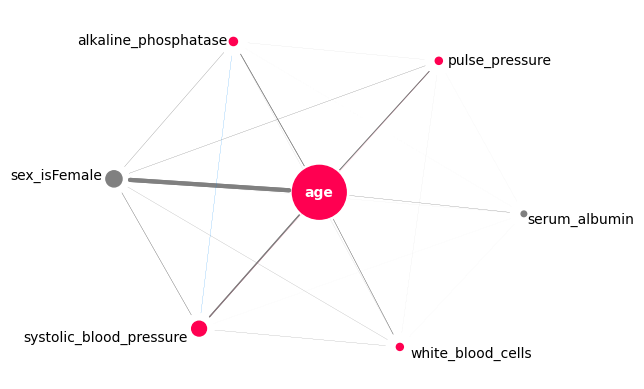

In [11]:
draw(
    psi=psi_2,
    r=r_2,
    psi_q25=psi_1_median,
    psi_q75=psi_1_median,
    r_q25=r_1_q_lower,
    r_q75=r_1_q_upper,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    negative_color=negative_color,
    positive_color=positive_color,
    uncertain_color='grey',
    output_path=os.path.join('..', '..', '..','..', 'result', 'nhanesi_rf_iqr_network.jpg')
)

## Experimenting with γ

To explore different tolerance levels, modify the `gamma` parameter above and re-run the notebook:

- **γ = 10**: Very permissive (40th-60th percentiles) → fewer gray nodes, more confident classifications
- **γ = 25**: Classical IQR (25th-75th percentiles) → balanced approach
- **γ = 35**: Stricter (15th-85th percentiles) → more gray nodes, highlighting heterogeneity
- **γ = 45**: Very strict (5th-95th percentiles) → maximum gray nodes, only very consistent effects classified

The parameter γ can be adjusted according to specific requirements:
- Use **smaller γ** when you want to emphasize dominant patterns
- Use **larger γ** when you want to be conservative and highlight patient heterogeneity